In [73]:
import numpy as np
import xarray as xr
import rioxarray as rxr
from affine import Affine
import geopandas as gpd
import matplotlib.pyplot as plt
from odc.geo.xr import ODCExtensionDa

In [75]:
acag = rxr.open_rasterio("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/acag/pm25/raw/GL/Annual/V6GL02.04.CNNPM25.GL.199801-199812.nc", decode_coords="all", mask_and_scale=True, driver="HDF5")


SP       = 0.01  # degrees
acag["x"] = acag["x"] * SP - 180
acag["y"] = acag["y"] * SP - 60
acag = acag.rename(x="longitude", y="latitude")

# ── Set geo properties ──────────────────────────────────────────
# 1. Tell rioxarray which dims are x/y
acag = acag.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

# 2. Write CRS (WGS84 = EPSG:4326)
acag = acag.rio.write_crs("EPSG:4326")

# Drop NAs
acag = acag.where(acag >= 0)

# Decrease precision
acag = acag.astype("float32")

/scicore/home/meiera/schulz0022/miniforge-pypy3/envs/gnt/lib/python3.11/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


In [82]:
acag.to_dataset(name="PM25")

<xarray.Dataset> Size: 2GB
Dimensions:      (band: 1, longitude: 36000, latitude: 13000)
Coordinates:
  * band         (band) int64 8B 1
  * longitude    (longitude) float64 288kB -180.0 -180.0 -180.0 ... 180.0 180.0
  * latitude     (latitude) float64 104kB -59.99 -59.98 -59.98 ... 69.99 70.0
    spatial_ref  int64 8B 0
Data variables:
    PM25         (band, latitude, longitude) float32 2GB 0.0 0.0 0.0 ... 0.0 0.0

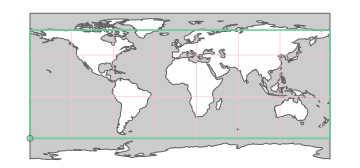

In [76]:
acag.odc.geobox

In [58]:
gadm = gpd.read_file("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/misc/processed/stage_1/gadm/gadm_levelADM_0_simplified.gpkg")

In [66]:
senegal = gadm.query("COUNTRY == 'Senegal'")

<Axes: title={'center': 'band = 1, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

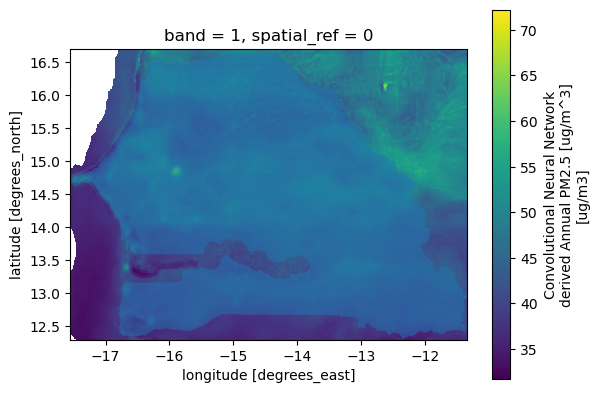

In [77]:
fig, ax = plt.subplots()

acag.rio.clip_box(*senegal.total_bounds).squeeze().plot.imshow(ax=ax)
senegal.plot(ax=ax, alpha=.5)

---

In [1]:
import pandas as pd

In [2]:
test_parquet = pd.read_parquet("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/50km.parquet")

In [9]:
test_parquet[["viirs_annual", "ntl_harm", "pm25"]].corr()

,viirs_annual,ntl_harm,pm25
viirs_annual,1.000000,0.613870,0.051131
ntl_harm,0.613870,1.000000,0.086442
pm25,0.051131,0.086442,1.000000


In [6]:
test_parquet.dropna(subset=["pm25"])

,pixel_id,year,modis_median,modis_mean,modis_rollmax3,modis_gt30C,avhrr_median,avhrr_mean,avhrr_rollmax3,avhrr_gt30C,...,HDI_HI_1999,WB_LO_1999,HDI_ME_1999,HDI_HI_1991,WB_LO_1991,HDI_HI_2011,HDI_VH_2011,WB_LM_2011,ix,iy
456,216,1998,NaN,NaN,NaN,NaN,292.994809,288.695477,298.931685,1.423317,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
457,216,1999,NaN,NaN,NaN,NaN,290.668868,288.553777,292.258589,1.772903,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
459,216,2001,259.518962,261.625801,286.313569,NaN,288.817634,287.293417,295.984335,1.310675,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
460,216,2002,266.663936,265.216687,292.815412,NaN,292.770940,292.474737,301.995050,4.170874,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
461,216,2003,265.205741,264.374620,292.550897,NaN,292.145319,291.925300,302.901661,3.336544,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982245,2533442294120732,2017,297.034914,296.976810,298.706267,2.713352,297.000527,296.400676,302.330000,1.595818,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9,39
1982246,2533442294120732,2018,296.910348,296.858674,298.862974,2.011185,290.980872,289.611142,NaN,1.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9,39
1982247,2533442294120732,2019,297.012882,296.935774,298.736075,2.885430,293.153418,292.449715,NaN,NaN,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9,39
1982248,2533442294120732,2020,297.118392,297.101028,299.457964,2.975937,289.621119,289.621119,NaN,NaN,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9,39
